# Chapter 2 - Analysis Notebook

Reproduces every figure and in-text statistic in **Chapter 2: The National Identification Trend, SY2005-06 to SY2023-24**.

Inputs: `idea_db_v2.sqlite`. Outputs: PNG figures in `figures/`. Run top-to-bottom; no network required.

In [1]:
import sqlite3, os
import pandas as pd
import matplotlib.pyplot as plt

DB = '../_shared/idea_db_v2.sqlite'
FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)
con = sqlite3.connect(DB)
def q(sql, params=()):
    return pd.read_sql_query(sql, con, params=params)
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

## 1. National rate series and three-regime view (Figures 2.1, 2.2)

Numerator: sum of (disability='ALL', age='ALL') counts. Denominator: sum of PK-12 enrollment. National rate aggregates before dividing.

,sy,served,enroll,pct,n_states_included
0,2005-06,6712605,49113298,13.668,51
1,2006-07,6686361,49315842,13.558,51
2,2007-08,6595833,49198469,13.407,50
3,2008-09,6483372,49171947,13.185,50
4,2009-10,6480540,49360982,13.129,51
5,2010-11,6434916,49484181,13.004,51
6,2011-12,6401238,49521669,12.926,51
7,2012-13,6417448,49679585,12.918,50
8,2013-14,6452103,49951790,12.917,50
9,2014-15,6552210,50218514,13.047,50


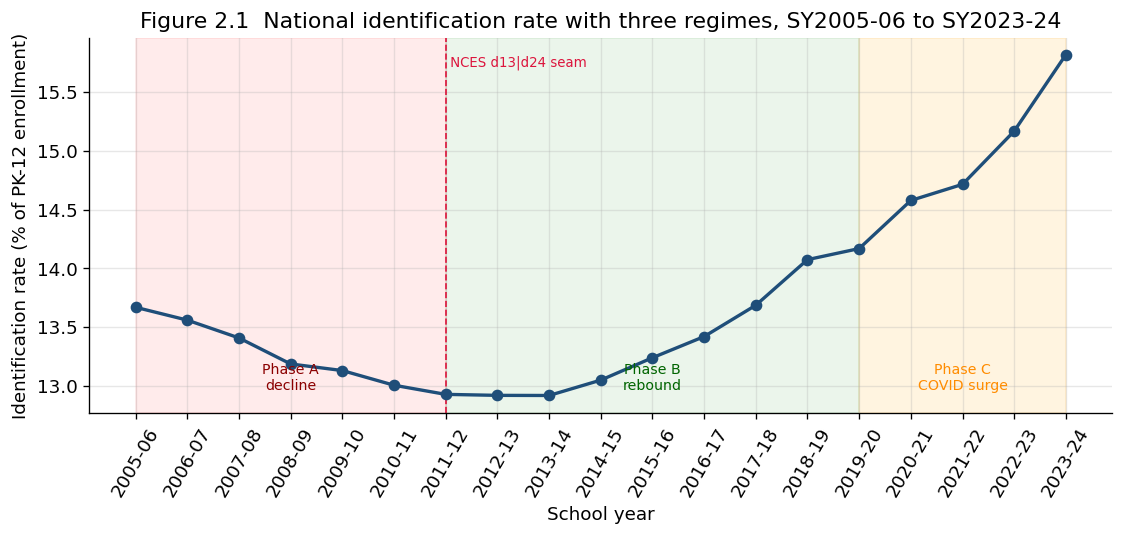

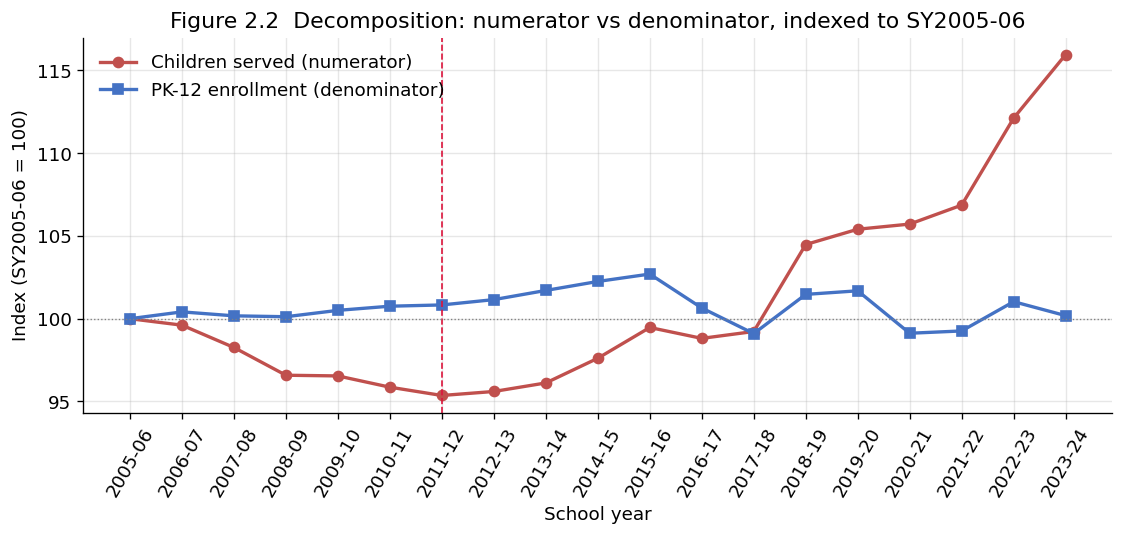

In [2]:
# 분모 비대칭 제거: raw 직접 SUM 대신 v_identification_rate_national 사용.
# served/enroll 는 이제 같은 주 집합(분자 결측 주 제외)으로 일관 집계된다.
# 컬럼명(sy/served/enroll/pct)은 다운스트림(phase delta, seam) 호환 위해 보존.
nat = q('''
  SELECT school_year   AS sy,
         total_served   AS served,
         total_enrolled AS enroll,
         pct_identified AS pct,
         n_states_included
  FROM v_identification_rate_national
  ORDER BY school_year''')

# Figure 2.1 - rate with three regimes
fig, ax = plt.subplots(figsize=(9.5,4.6))
ax.plot(nat['sy'], nat['pct'], marker='o', color='#1f4e79', lw=2, zorder=3)
ax.axvspan('2005-06','2011-12', alpha=0.08, color='red')
ax.axvspan('2011-12','2019-20', alpha=0.08, color='green')
ax.axvspan('2019-20','2023-24', alpha=0.12, color='orange')
ax.axvline('2011-12', color='crimson', ls='--', lw=1)
ymin = nat['pct'].min()
ax.text('2008-09', ymin+0.05, 'Phase A\ndecline', ha='center', fontsize=8.5, color='darkred')
ax.text('2015-16', ymin+0.05, 'Phase B\nrebound', ha='center', fontsize=8.5, color='darkgreen')
ax.text('2021-22', ymin+0.05, 'Phase C\nCOVID surge', ha='center', fontsize=8.5, color='darkorange')
ax.text('2011-12', nat['pct'].max(), ' NCES d13|d24 seam', color='crimson', fontsize=8, va='top')
ax.set_ylabel('Identification rate (% of PK-12 enrollment)'); ax.set_xlabel('School year')
ax.tick_params(axis='x', rotation=60)
ax.set_title('Figure 2.1  National identification rate with three regimes, SY2005-06 to SY2023-24')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig2_1_rate_phases.png', bbox_inches='tight')

# Figure 2.2 - numerator/denominator decomposition (index 2005-06=100)
# 주의: served/enroll 은 연도별 포함 주 집합 기준(억제 연도는 주 수 < 51).
# 따라서 지수는 식별행위 변화 외에 포함 주 구성 변화도 일부 반영한다.
b_n = nat['served'].iloc[0]; b_e = nat['enroll'].iloc[0]
fig, ax = plt.subplots(figsize=(9.5,4.6))
ax.plot(nat['sy'], 100*nat['served']/b_n, marker='o', color='#c0504d', lw=2, label='Children served (numerator)')
ax.plot(nat['sy'], 100*nat['enroll']/b_e, marker='s', color='#4472c4', lw=2, label='PK-12 enrollment (denominator)')
ax.axvline('2011-12', color='crimson', ls='--', lw=1)
ax.axhline(100, color='gray', lw=0.8, ls=':')
ax.set_ylabel('Index (SY2005-06 = 100)'); ax.set_xlabel('School year')
ax.tick_params(axis='x', rotation=60); ax.legend(frameon=False, loc='upper left')
ax.set_title('Figure 2.2  Decomposition: numerator vs denominator, indexed to SY2005-06')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig2_2_decomposition.png', bbox_inches='tight')
nat[['sy','served','enroll','pct','n_states_included']].round(3)

## 2. Phase deltas (Table 2.1 inputs)

The decomposition that distinguishes a numerator-driven move from a denominator-driven one. The COVID jump (SY2019-20 -> SY2020-21) is the diagnostic case: the rate rises while the numerator barely moves.

In [3]:
d = nat.set_index('sy')
def delta(a, b):
    return pd.Series({
        'served_pct_change': 100*(d.loc[b,'served']/d.loc[a,'served']-1),
        'enroll_pct_change': 100*(d.loc[b,'enroll']/d.loc[a,'enroll']-1),
        'rate_pp_change':    d.loc[b,'pct'] - d.loc[a,'pct'],
    })
phases = pd.DataFrame({
    'A: 2005-06->2011-12':           delta('2005-06','2011-12'),
    'B: 2011-12->2019-20':           delta('2011-12','2019-20'),
    'COVID jump: 2019-20->2020-21':  delta('2019-20','2020-21'),
    'C: 2019-20->2023-24':           delta('2019-20','2023-24'),
}).T
phases.round(2)

,served_pct_change,enroll_pct_change,rate_pp_change
A: 2005-06->2011-12,-4.64,0.83,-0.74
B: 2011-12->2019-20,10.53,0.85,1.24
COVID jump: 2019-20->2020-21,0.30,-2.52,0.41
C: 2019-20->2023-24,10.01,-1.47,1.65


## 3. Seam sensitivity check

The d13->d24 edition change falls at SY2011-12. We cannot re-derive the missing edition, but we can show the rate change *across* the seam is of the same small magnitude as adjacent within-edition year-to-year changes - i.e. the seam does not coincide with an outsized jump.

In [4]:
nat['rate_diff'] = nat['pct'].diff()
seam = nat.loc[nat['sy']=='2011-12','rate_diff'].iloc[0]
adj = nat[nat['sy'].between('2008-09','2014-15')][['sy','rate_diff']]
print(f"Rate change across seam (SY2010-11 -> SY2011-12): {seam:+.3f} pp")
print('Adjacent within-window year-over-year changes:')
print(adj.to_string(index=False))

Rate change across seam (SY2010-11 -> SY2011-12): -0.078 pp
Adjacent within-window year-over-year changes:
     sy  rate_diff
2008-09  -0.221479
2009-10  -0.056232
2010-11  -0.124886
2011-12  -0.077851
2012-13  -0.008459
2013-14  -0.001016
2014-15   0.130739


In [5]:
con.close()
print('Chapter 2 figures written to', FIGDIR)

Chapter 2 figures written to figures
